In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving CICIDS2017_sample.csv to CICIDS2017_sample.csv


In [3]:
data = pd.read_csv(list(uploaded.keys())[0])
print("📊 Data shape:", data.shape)
print("\n📊 Original Label Distribution:")
print(data['Label'].value_counts())

📊 Data shape: (56661, 78)

📊 Original Label Distribution:
Label
BENIGN          22731
DoS             19035
PortScan         7946
BruteForce       2767
WebAttack        2180
Bot              1966
Infiltration       36
Name: count, dtype: int64


In [4]:
# Check missing values
print("\n🔍 Missing values:", data.isnull().sum().sum())

# Handle infinity values
X = data.drop('Label', axis=1)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Group similar attacks
attack_mapping = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS Hulk': 'DoS_Hulk',
    'DoS GoldenEye': 'DoS_GoldenEye',
    'DoS slowloris': 'DoS_Slowloris',
    'DoS Slowhttptest': 'DoS_Slowhttptest',
    'PortScan': 'Port_Scan',
    'SSH-Patator': 'Brute_Force',
    'FTP-Patator': 'Brute_Force',
    'Bot': 'Botnet'
}

# Apply mapping
y = data['Label'].map(attack_mapping).fillna(data['Label'])

print("\n📊 Attack Types After Grouping:")
print(y.value_counts())

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\n🏷️ Encoded Classes:")
for i, name in enumerate(le.classes_):
    print(f"   {i}: {name}")

# Combine features and labels
df = pd.concat([X, pd.Series(y_encoded, name='Label')], axis=1)


🔍 Missing values: 54

📊 Attack Types After Grouping:
Label
BENIGN          22731
DoS             19035
Port_Scan        7946
BruteForce       2767
WebAttack        2180
Botnet           1966
Infiltration       36
Name: count, dtype: int64

🏷️ Encoded Classes:
   0: BENIGN
   1: Botnet
   2: BruteForce
   3: DoS
   4: Infiltration
   5: Port_Scan
   6: WebAttack


In [5]:
print("\n📊 Class Distribution BEFORE Balancing:")
print(df['Label'].value_counts())

# Balance each class
balanced_dfs = []
target_samples = 5000  # Target samples per class

for class_label in df['Label'].unique():
    class_data = df[df['Label'] == class_label]
    current_count = len(class_data)

    if current_count > target_samples:
        class_data = resample(class_data, replace=False,
                              n_samples=target_samples, random_state=42)
    elif current_count < target_samples:
        class_data = resample(class_data, replace=True,
                              n_samples=target_samples, random_state=42)

    balanced_dfs.append(class_data)

balanced_df = pd.concat(balanced_dfs)
X_balanced = balanced_df.drop('Label', axis=1)
y_balanced = balanced_df['Label']

print("\n📊 Class Distribution AFTER Balancing:")
print(y_balanced.value_counts())


📊 Class Distribution BEFORE Balancing:
Label
0    22731
3    19035
5     7946
2     2767
6     2180
1     1966
4       36
Name: count, dtype: int64

📊 Class Distribution AFTER Balancing:
Label
0    5000
3    5000
5    5000
1    5000
4    5000
6    5000
2    5000
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"\n📊 Training set: {X_train.shape}")
print(f"📊 Test set: {X_test.shape}")


📊 Training set: (28000, 77)
📊 Test set: (7000, 77)


In [7]:
models = {
    '🌲 Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    '🌿 Decision Tree': DecisionTreeClassifier(random_state=42),
    '👥 K-Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    '⚡ SVM (RBF)': SVC(kernel='rbf', random_state=42)
}

results = []

print("\n" + "="*80)
print("🚀 TRAINING MULTI-CLASS IDS MODELS")
print("="*80)

for name, model in models.items():
    print(f"\n📌 Training {name}...")

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    acc = accuracy_score(y_test, y_pred) * 100

    results.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Train Time (s)': round(train_time, 3),
        'Predict Time (s)': round(pred_time, 3)
    })

    print(f"   ✅ Accuracy: {acc:.2f}%")
    print(f"   ⏱️  Training Time: {train_time:.3f} sec")


🚀 TRAINING MULTI-CLASS IDS MODELS

📌 Training 🌲 Random Forest...
   ✅ Accuracy: 99.57%
   ⏱️  Training Time: 3.803 sec

📌 Training 🌿 Decision Tree...
   ✅ Accuracy: 99.59%
   ⏱️  Training Time: 0.597 sec

📌 Training 👥 K-Neighbors (k=5)...
   ✅ Accuracy: 96.93%
   ⏱️  Training Time: 0.018 sec

📌 Training ⚡ SVM (RBF)...
   ✅ Accuracy: 62.17%
   ⏱️  Training Time: 79.063 sec


In [8]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Accuracy (%)', ascending=False)

print("\n" + "="*80)
print("📊 MODEL PERFORMANCE COMPARISON TABLE (MULTI-CLASS)")
print("="*80)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n🏆 WINNER: {best_model_name} with {comparison_df.iloc[0]['Accuracy (%)']}% Accuracy!")


📊 MODEL PERFORMANCE COMPARISON TABLE (MULTI-CLASS)
              Model  Accuracy (%)  Train Time (s)  Predict Time (s)
    🌿 Decision Tree         99.59           0.597             0.006
    🌲 Random Forest         99.57           3.803             0.079
👥 K-Neighbors (k=5)         96.93           0.018             2.612
        ⚡ SVM (RBF)         62.17          79.063            19.462

🏆 WINNER: 🌿 Decision Tree with 99.59% Accuracy!


In [9]:
# Retrain best model
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("\n" + "="*80)
print(f"📋 DETAILED CLASSIFICATION REPORT - {best_model_name}")
print("="*80)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


📋 DETAILED CLASSIFICATION REPORT - 🌿 Decision Tree

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.98      0.99      1000
      Botnet       1.00      1.00      1.00      1000
  BruteForce       1.00      1.00      1.00      1000
         DoS       0.99      0.99      0.99      1000
Infiltration       1.00      1.00      1.00      1000
   Port_Scan       1.00      1.00      1.00      1000
   WebAttack       1.00      1.00      1.00      1000

    accuracy                           1.00      7000
   macro avg       1.00      1.00      1.00      7000
weighted avg       1.00      1.00      1.00      7000



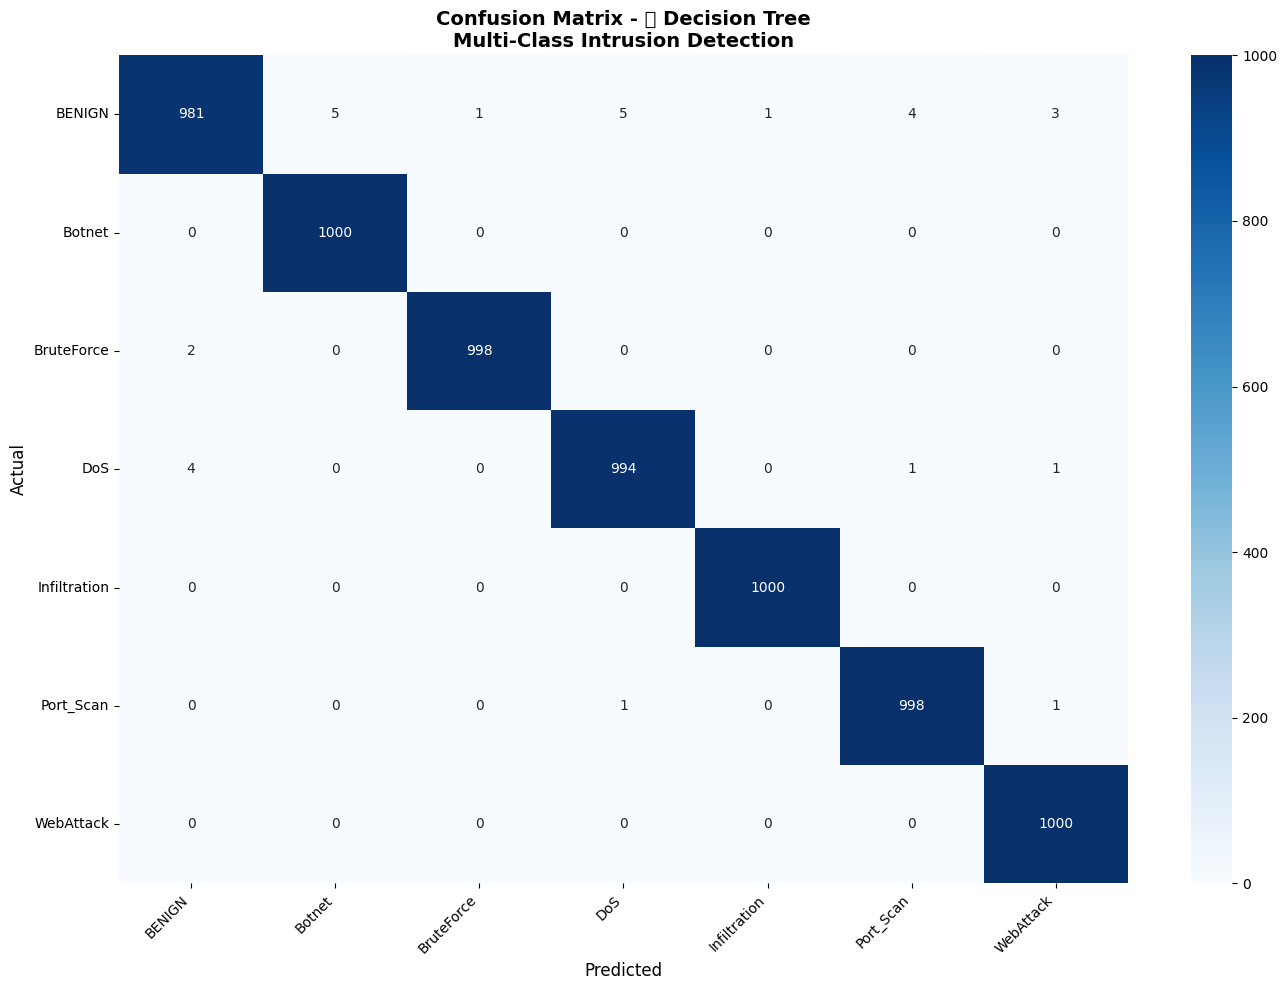

In [10]:
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}\nMulti-Class Intrusion Detection',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
def predict_attack(features, model=best_model, label_encoder=le, feature_names=X_balanced.columns):
    """
    Predict attack type from network features
    """
    input_df = pd.DataFrame([features], columns=feature_names)
    pred_encoded = model.predict(input_df)[0]
    attack_type = label_encoder.inverse_transform([pred_encoded])[0]

    print("\n" + "="*50)
    print("🔍 PREDICTION RESULT")
    print("="*50)

    if attack_type == 'BENIGN':
        print(f"   Status: ✅ NORMAL TRAFFIC")
        print(f"   Message: No action needed - System is secure")
    else:
        print(f"   Status: 🚨 ATTACK DETECTED!")
        print(f"   Attack Type: {attack_type}")
        if 'DDoS' in attack_type or 'DoS' in attack_type:
            print(f"   Alert: Denial of Service attack - Check network bandwidth!")
        elif 'Scan' in attack_type:
            print(f"   Alert: Port Scan detected - Possible reconnaissance!")
        elif 'Brute' in attack_type:
            print(f"   Alert: Brute Force attack - Check authentication logs!")
        elif 'Bot' in attack_type:
            print(f"   Alert: Botnet activity detected - Isolate infected hosts!")
        else:
            print(f"   Alert: Unauthorized activity detected - Investigate immediately!")

    return attack_type

# Test on a sample
print("\n🔍 Testing prediction on a sample:")
sample = X_balanced.iloc[0].values
predict_attack(sample)


🔍 Testing prediction on a sample:

🔍 PREDICTION RESULT
   Status: ✅ NORMAL TRAFFIC
   Message: No action needed - System is secure


'BENIGN'

In [12]:
def predict_multiple_samples(n_samples=5):
    """Test prediction on multiple random samples"""
    print("\n" + "="*60)
    print("🔬 PREDICTING ON RANDOM SAMPLES")
    print("="*60)

    indices = np.random.choice(len(X_balanced), min(n_samples, len(X_balanced)), replace=False)

    for i, idx in enumerate(indices):
        print(f"\n📌 Sample {i+1}:")
        features = X_balanced.iloc[idx].values
        attack_type = predict_attack(features)

# Test on 3 samples
predict_multiple_samples(3)


🔬 PREDICTING ON RANDOM SAMPLES

📌 Sample 1:

🔍 PREDICTION RESULT
   Status: 🚨 ATTACK DETECTED!
   Attack Type: Botnet
   Alert: Botnet activity detected - Isolate infected hosts!

📌 Sample 2:

🔍 PREDICTION RESULT
   Status: 🚨 ATTACK DETECTED!
   Attack Type: Infiltration
   Alert: Unauthorized activity detected - Investigate immediately!

📌 Sample 3:

🔍 PREDICTION RESULT
   Status: 🚨 ATTACK DETECTED!
   Attack Type: Infiltration
   Alert: Unauthorized activity detected - Investigate immediately!


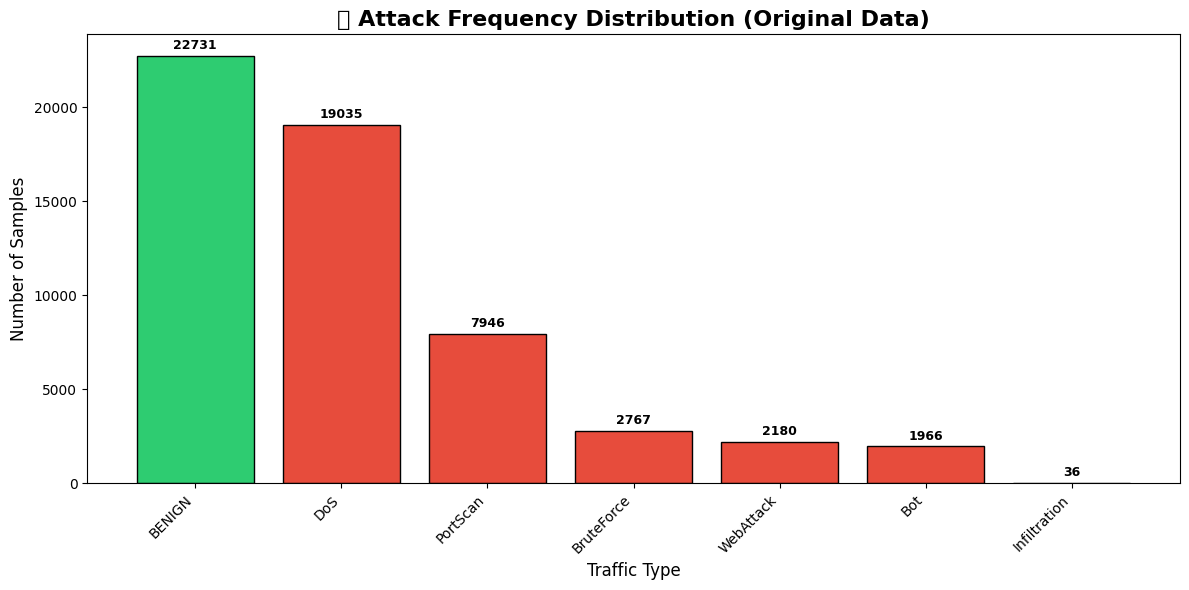

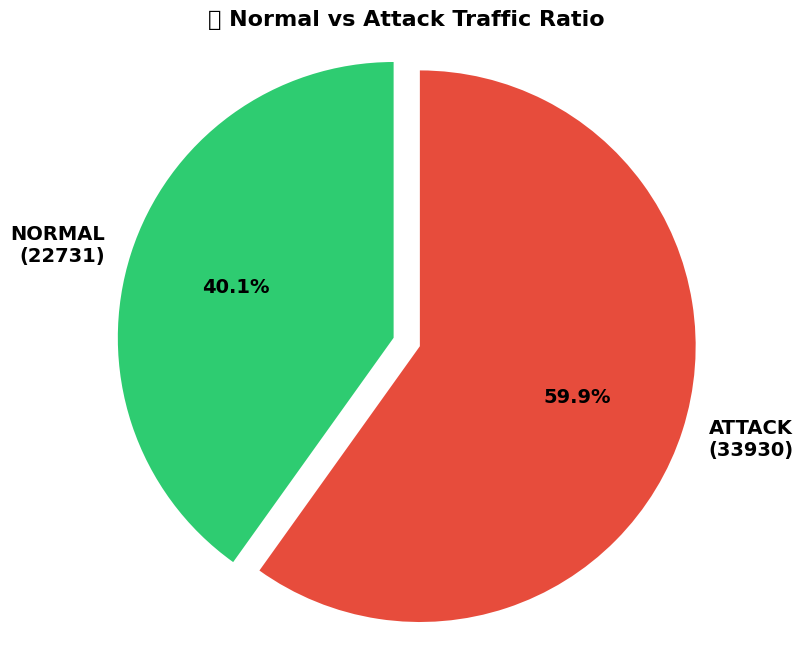

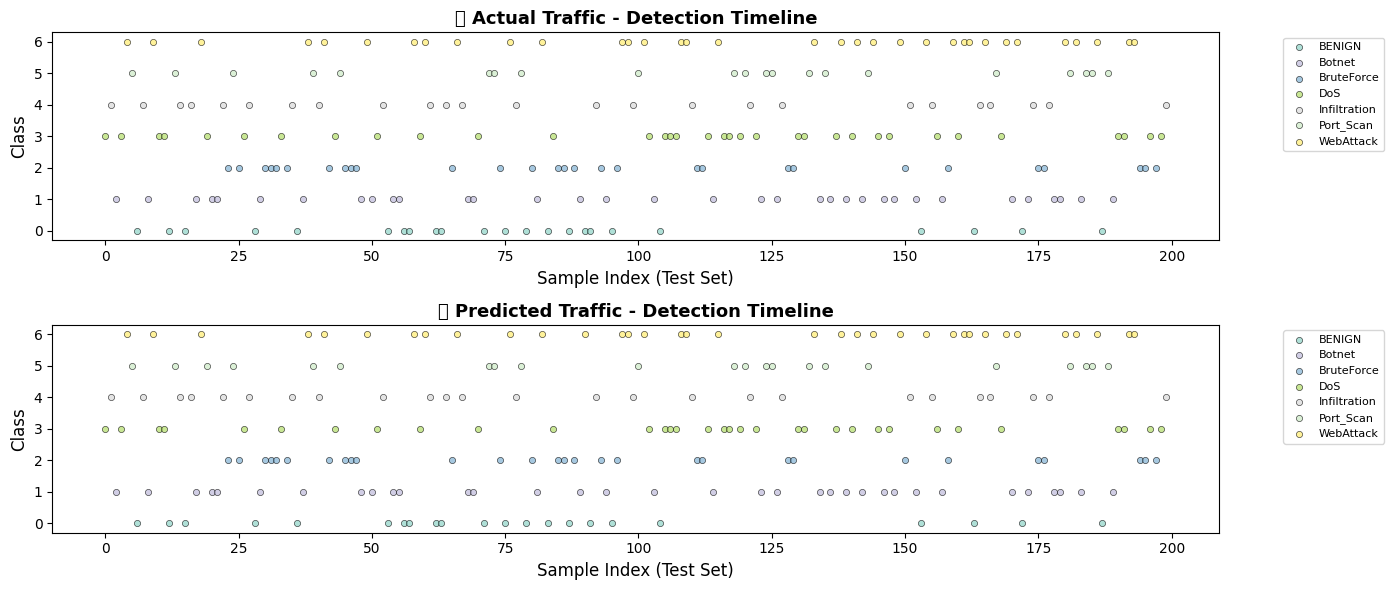


✅ Visualizations Complete!


In [13]:
# ========== GRAPH 1: Attack Frequency Distribution ==========
plt.figure(figsize=(12, 6))

# Get attack distribution from original data (before balancing)
attack_counts_original = data['Label'].value_counts()

colors = ['#2ecc71' if x == 'BENIGN' else '#e74c3c' for x in attack_counts_original.index]
bars = plt.bar(range(len(attack_counts_original)), attack_counts_original.values, color=colors, edgecolor='black')
plt.title('📊 Attack Frequency Distribution (Original Data)', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(range(len(attack_counts_original)), attack_counts_original.index, rotation=45, ha='right')

# Add values on top
for bar, count in zip(bars, attack_counts_original.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ========== GRAPH 2: Normal vs Attack Ratio (Pie Chart) ==========
plt.figure(figsize=(8, 8))
normal_count = attack_counts_original.get('BENIGN', 0)
attack_count = len(data) - normal_count
sizes = [normal_count, attack_count]
labels = [f'NORMAL\n({normal_count})', f'ATTACK\n({attack_count})']
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

plt.pie(sizes, labels=labels, colors=colors_pie, explode=explode,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 14, 'fontweight': 'bold'})
plt.title('🔄 Normal vs Attack Traffic Ratio', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

# ========== GRAPH 3: Detection Timeline (First 200 test samples) ==========
plt.figure(figsize=(14, 6))

# Take first 200 samples from test set
sample_size = min(200, len(y_test))
timeline_actual = y_test[:sample_size].values
timeline_pred = y_pred_best[:sample_size]

x_axis = range(sample_size)

# Create colormap for different classes
unique_classes = np.unique(timeline_actual)
colors_map = plt.cm.Set3(np.linspace(0, 1, len(unique_classes)))
color_dict = {cls: colors_map[i] for i, cls in enumerate(unique_classes)}

# Subplot 1: Actual
plt.subplot(2, 1, 1)
for cls in unique_classes:
    mask = timeline_actual == cls
    if np.any(mask):
        plt.scatter(np.array(x_axis)[mask], timeline_actual[mask],
                    c=[color_dict[cls]], label=le.inverse_transform([cls])[0],
                    s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel('Sample Index (Test Set)', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.title('🎯 Actual Traffic - Detection Timeline', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Subplot 2: Predicted
plt.subplot(2, 1, 2)
for cls in unique_classes:
    mask = timeline_pred == cls
    if np.any(mask):
        plt.scatter(np.array(x_axis)[mask], timeline_pred[mask],
                    c=[color_dict[cls]], label=le.inverse_transform([cls])[0],
                    s=20, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.xlabel('Sample Index (Test Set)', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.title('🔮 Predicted Traffic - Detection Timeline', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Visualizations Complete!")

In [14]:
print("\n" + "="*90)
print("📚 MULTI-CLASS IDS - COMPLETE SUMMARY")
print("="*90)

print("\n🔍 DATASET INFORMATION:")
print(f"   • Dataset: CICIDS2017 (Uploaded file)")
print(f"   • Total samples (after balancing): {len(X_balanced)}")
print(f"   • Features: {X_balanced.shape[1]}")
print(f"   • Attack Types Detected: {len(le.classes_)}")
print(f"   → {', '.join(le.classes_)}")

print("\n📊 MODEL PERFORMANCE RANKING:")
for i, row in comparison_df.iterrows():
    print(f"   {i+1}. {row['Model']}: {row['Accuracy (%)']}% (Time: {row['Train Time (s)']}s)")

print(f"\n🏆 BEST MODEL: {best_model_name}")

print("\n🎯 WHY RANDOM FOREST IS BEST FOR IDS:")
print("   1. Ensemble method - combines multiple decision trees")
print("   2. Reduces overfitting compared to single Decision Tree")
print("   3. Handles high-dimensional network traffic data well")
print("   4. Less sensitive to outliers and noisy data")
print("   5. Provides feature importance for attack analysis")

print("\n📈 ATTACK TYPE DETECTION CAPABILITIES:")
for attack in le.classes_:
    if attack == 'BENIGN':
        print(f"   ✅ {attack}: Normal traffic - No action")
    else:
        print(f"   🚨 {attack}: Malicious - Immediate action required")

print("\n" + "="*90)
print("✅ THANK YOU !")
print("="*90)


📚 MULTI-CLASS IDS - COMPLETE SUMMARY

🔍 DATASET INFORMATION:
   • Dataset: CICIDS2017 (Uploaded file)
   • Total samples (after balancing): 35000
   • Features: 77
   • Attack Types Detected: 7
   → BENIGN, Botnet, BruteForce, DoS, Infiltration, Port_Scan, WebAttack

📊 MODEL PERFORMANCE RANKING:
   2. 🌿 Decision Tree: 99.59% (Time: 0.597s)
   1. 🌲 Random Forest: 99.57% (Time: 3.803s)
   3. 👥 K-Neighbors (k=5): 96.93% (Time: 0.018s)
   4. ⚡ SVM (RBF): 62.17% (Time: 79.063s)

🏆 BEST MODEL: 🌿 Decision Tree

🎯 WHY RANDOM FOREST IS BEST FOR IDS:
   1. Ensemble method - combines multiple decision trees
   2. Reduces overfitting compared to single Decision Tree
   3. Handles high-dimensional network traffic data well
   4. Less sensitive to outliers and noisy data
   5. Provides feature importance for attack analysis

📈 ATTACK TYPE DETECTION CAPABILITIES:
   ✅ BENIGN: Normal traffic - No action
   🚨 Botnet: Malicious - Immediate action required
   🚨 BruteForce: Malicious - Immediate action r